In [1]:
%load_ext autoreload
%autoreload 2
import sys
import torch
print(f"Python path: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import sys
import os
import gymnasium.spaces as spaces
from types import SimpleNamespace
sys.path.append(os.getcwd())
from utils.env import make_env
from certificate import CertificateNet
from model import ACModel
from data_gen_mod import generate_transitions
import matplotlib.pyplot as plt
from minigrid.wrappers import RGBImgObsWrapper

Python path: C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Scripts\python.exe
PyTorch version: 2.9.1+cpu
GPU available: False


C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Generating State Space (Full 8x8 Grid)...
DYNAMIC OBSTACLES REACHED--------------------------------------00
DYNAMIC OBSTACLES REACHED--------------------------------------00
_____-----____


DYNAMIC OBSTACLES REACHED--------------------------------------00


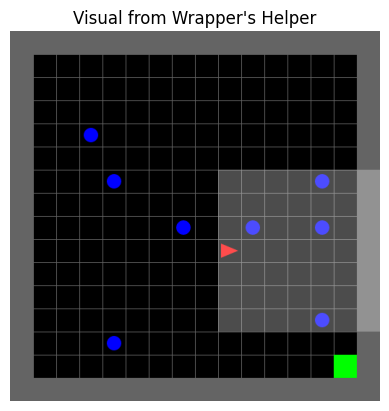

In [2]:
ENV_NAME = "MiniGrid-Dynamic-Obstacles-16x16-v0"
env = make_env(ENV_NAME, seed=6)

# all_actions = np.arange(env.action_space.n)
# available_actions = [a for a in all_actions if a != 1]
# random_action = np.random.choice(available_actions)
# print(type(random_action))

# obs=env.get_temp_state(1,1,0)

#### see the env ----------- 
# visual_image=env.render()  # returns image
# print(visual_image)
# plt.imshow(visual_image)
# plt.show()
#-----------
base_env=env.unwrapped

############################ FORCING AN AGENT'S STATE ##########################
# base_env.agent_pos = (4,6)
# obs = base_env.gen_obs() # returns tensor in a dictionary
# grid_matrix = obs['image']  # Shape is usually (7, 7, 3)
# full_obs = env.observation(obs)
# print(grid_matrix) #16,16,3

# ===> agent view
# plt.title("Agent's Input (Object IDs)")
# plt.imshow(full_obs['image'][:, :, 0], cmap='tab20') 
# plt.colorbar()
# plt.show()

# view 
# env.load_state_from_tensor(full_obs['image'])
# visual_image = env.render()
# plt.imshow(visual_image)
# plt.title("Visual from Wrapper's Helper")
# plt.axis('off')
# plt.show()
#--------------------------------------------------------------------------------#
################ render from env's raw obs
obs = base_env.gen_obs()
obs2=env.observation(obs)
env.load_state_from_tensor(obs2['image'])
visual_image2 = env.render()
plt.imshow(visual_image2)
plt.title("Visual from Wrapper's Helper")
plt.axis('off')
plt.show()
#-------------------------------------------
############### render from CNN ready tensor
# base_env.agent_pos = (4,2)
# obs = base_env.gen_obs()
# obs2=env.observation(obs)
# batch_numpy = np.stack(obs2['image'])
# batch_tensor = torch.tensor(batch_numpy, dtype=torch.float32, device='cpu')
# env.load_state_from_tensor(batch_tensor)
# visual_image2 = env.render()
# plt.imshow(visual_image2)
# plt.title("Visual from Wrapper's Helper")
# plt.axis('off')
# plt.show()
#-------------------------------------------
################# get next state by step
# base_env.agent_pos = (4,7)
# base_env.agent_dir = 3
# # for e in range(50): 
# obs,_,ter,_,_=env.step(2)
# print(ter)
# obs = base_env.gen_obs() # returns tensor in a dictionary
# full_obs = env.observation(obs)
# print(full_obs['image'])
#     # visual_image = env.render()
#     # plt.imshow(visual_image)
#     # plt.title("Visual from Wrapper's Helper")
#     # plt.axis('off')
#     # plt.show()
# env.load_state_from_tensor(full_obs['image'])
# visual_image = env.render()
# plt.imshow(visual_image)
# plt.title("Visual from Wrapper's Helper")
# plt.axis('off')
# plt.show()
#-------------------------------------------
#### get next action by policy
# import utils
# class ObsBatch:
#     def __init__(self, tensor):
#         self.image = tensor
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# MODEL_PATH = "storage/randomenv_ranreward_16_v1/status.pt" 
# dummy_obs_space = {"image": (16, 16, 3)}
# policy = ACModel(dummy_obs_space, env.action_space)
# checkpoint = torch.load(MODEL_PATH)
# policy.load_state_dict(checkpoint["model_state"])
# policy.to(device)

# _, preprocess_obss = utils.get_obss_preprocessor(env.observation_space)
# obs=[]
# base_env.agent_dir=0
# base_env.agent_pos=(6,9)
# o = base_env.gen_obs() 
# full_obs = env.observation(o)
# env.load_state_from_tensor(full_obs['image'])
# visual_image = env.render()
# plt.imshow(visual_image)
# plt.title("Visual from Wrapper's Helper")
# plt.axis('off')
# plt.show()
# obs.append(env.observation(base_env.gen_obs())['image'])

# base_env.agent_pos=(8,9)
# o = base_env.gen_obs() 
# full_obs = env.observation(o)
# env.load_state_from_tensor(full_obs['image'])
# visual_image = env.render()
# plt.imshow(visual_image)
# plt.title("Visual from Wrapper's Helper")
# plt.axis('off')
# plt.show()
# obs.append(env.observation(base_env.gen_obs())['image'])

# batch_numpy = np.stack(obs)
# batch_tensor = torch.tensor(batch_numpy, dtype=torch.float32, device=device)
# print(batch_tensor.shape)
# obs=ObsBatch(batch_tensor)
# # obs=preprocess_obss([obs])
# dist,_,_=policy(obs,None)
# action=dist.probs.max(1,keepdim=True)[1] 
# print(action)
#-------------------------------------------